In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Last inn datasettet fra lokal CSV-fil
file_path = "agaricus-lepiota.csv"  # Oppdater denne med korrekt filsti hvis nødvendig
kolonner = ["klasse", "cap-shape", "cap-surface", "cap-color", "bruises", "odor", "gill-attachment",
           "gill-spacing", "gill-size", "gill-color", "stalk-shape", "stalk-root", "stalk-surface-above-ring",
           "stalk-surface-below-ring", "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", 
           "veil-color", "ring-number", "ring-type", "spore-print-color", "population", "habitat"]

# Last inn data fra CSV-fil
data = pd.read_csv(file_path, header=None, names=kolonner)

# Konverter kategoriske variabler til numeriske verdier
label_encoders = {}
for kol in data.columns:
    le = LabelEncoder()
    data[kol] = le.fit_transform(data[kol])
    label_encoders[kol] = le

# Vis de første radene av dataen for å bekrefte at alt er lastet korrekt
data.head()


,klasse,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,2,0,2,0,6,2,1,1,3,...,3,7,7,1,2,2,5,6,3,2
1,2,6,3,5,2,7,1,0,2,5,...,2,8,8,0,3,1,4,2,4,6
2,0,6,3,10,2,0,1,0,0,5,...,2,8,8,0,3,1,4,3,2,1
3,0,0,3,9,2,3,1,0,0,6,...,2,8,8,0,3,1,4,3,2,4
4,2,6,4,9,2,7,1,0,2,6,...,2,8,8,0,3,1,4,2,4,6


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Bruk k-means og evaluer med silhouette score for forskjellige k-verdier
k_verdier = list(range(2, 31))
silhouette_scores = []

for k in k_verdier:
    kmeans = KMeans(n_clusters=k, random_state=42) # oppretter kmeans-modell som tar inn k antall klynger
    labels = kmeans.fit_predict(data) # Bruker kmeans-modellen til å predikere klynger
    silhouette_avg = silhouette_score(data, labels) # Bruker silhouette_score til å evaluere klyngene.
    silhouette_scores.append(silhouette_avg) # Legger til silhouette_score i en liste

# Print resultatene for silhouette score for hver verdi av k
silhouette_scores


[np.float64(0.3016737869081504),
 np.float64(0.26651379268070924),
 np.float64(0.2662415718725083),
 np.float64(0.2690971596029408),
 np.float64(0.2851371076726927),
 np.float64(0.2392860741095306),
 np.float64(0.2693403704283029),
 np.float64(0.2660090588673405),
 np.float64(0.27636618009508057),
 np.float64(0.27979337059653836),
 np.float64(0.24385707516433772),
 np.float64(0.24032953417058558),
 np.float64(0.24469012467274626),
 np.float64(0.24191692726210146),
 np.float64(0.24042112515016498),
 np.float64(0.23675131842739944),
 np.float64(0.24196059888329288),
 np.float64(0.24895187524605025),
 np.float64(0.23935292434544034),
 np.float64(0.2266914008263661),
 np.float64(0.2303814013870123),
 np.float64(0.2362850042833951),
 np.float64(0.22940934556205636),
 np.float64(0.22510292825054198),
 np.float64(0.20930117897062317),
 np.float64(0.21188283444874886),
 np.float64(0.2107751850883439),
 np.float64(0.21749096126554196),
 np.float64(0.21649035580734619)]

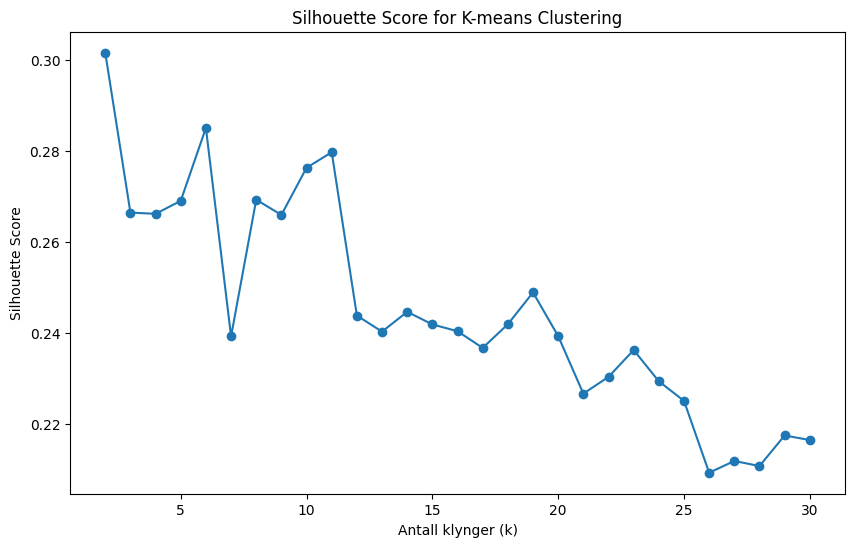

In [5]:
import matplotlib.pyplot as plt

# Plot silhouette score for hvert k
plt.figure(figsize=(10, 6))
plt.plot(k_verdier, silhouette_scores, marker='o')
plt.title("Silhouette Score for K-means Clustering")
plt.xlabel("Antall klynger (k)")
plt.ylabel("Silhouette Score")
plt.show()


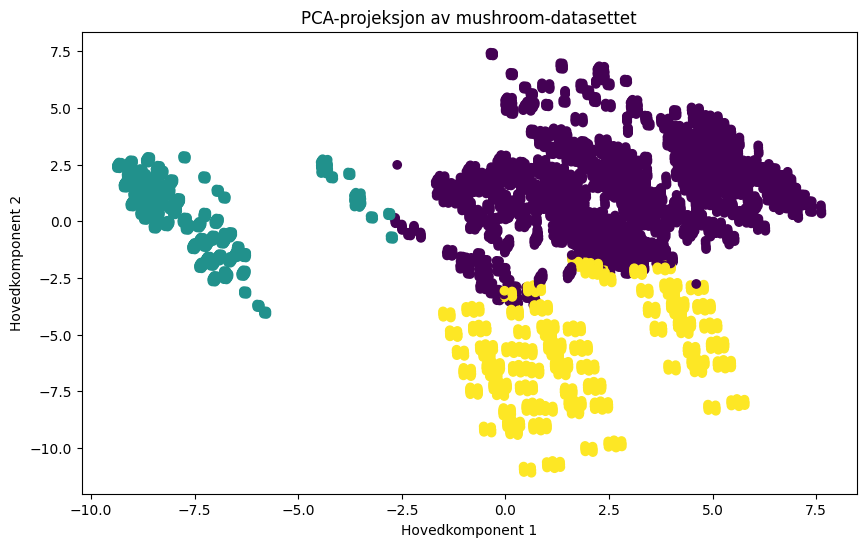

In [14]:
from sklearn.decomposition import PCA

# Reduser dimensjonaliteten ved hjelp av PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data)

# Velg et optimalt antall klynger basert på silhouette score
kmeans_optimal = KMeans(n_clusters=3, random_state=42)  # Juster k basert på tidligere resultater
labels_optimal = kmeans_optimal.fit_predict(data) # Prediker klynger

# Plot PCA-projeksjonen av dataen med klynger
plt.figure(figsize=(10, 6)) 
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels_optimal, cmap='viridis') # Plotter dataen med klynger
plt.title("PCA-projeksjon av mushroom-datasettet")
plt.xlabel("Hovedkomponent 1")
plt.ylabel("Hovedkomponent 2")
plt.show()
